Train events: 6 / 50
Test  events: 11 / 103
Test ROC-AUC: 0.6590909090909091

Confusion matrix (test):
 [[74 18]
 [ 8  3]]

Report (test):
               precision    recall  f1-score   support

           0      0.902     0.804     0.851        92
           1      0.143     0.273     0.188        11

    accuracy                          0.748       103
   macro avg      0.523     0.539     0.519       103
weighted avg      0.821     0.748     0.780       103


Coefficients (positive => higher event odds):
sstanom_q_mean          -0.914605
sstanom_q_mean_lag1     -0.882669
sstanom_lag2            -0.369831
sstanom_q_max            0.999055
sstanom_1yr_mean_lag1    1.634755
dtype: float64


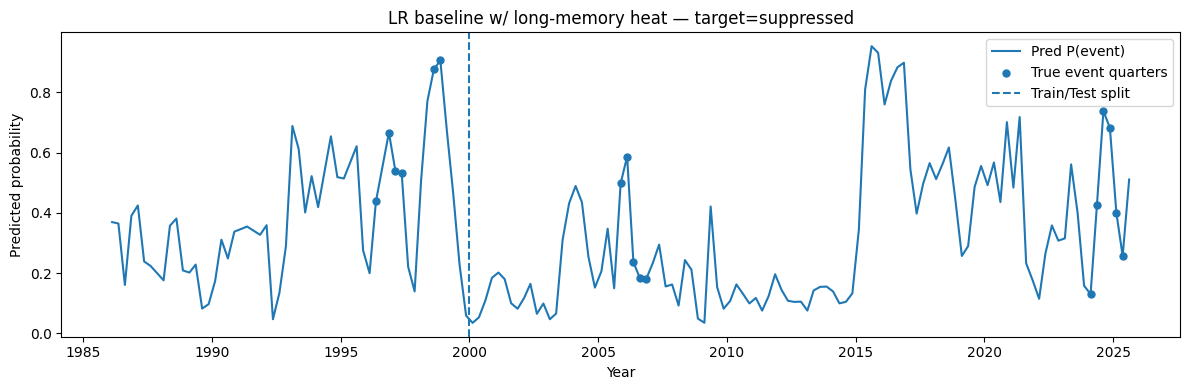

In [4]:
# It says: with OISST + these engineered features + this label + this time split, SST alone does not predict suppressed states well out-of-sample. That’s a valid result.
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

# load labeled table
df = pd.read_csv("../../1_DATA/processed/midcal/midcal_kelp_sst_labeled.csv",
                 index_col=0, parse_dates=True).sort_index()

# choose target
target = "suppressed"   # or "collapse"

# --- add "long before" heat history feature(s) ---
# previous-year mean anomaly ending last quarter
df["sstanom_1yr_mean_lag1"] = df["sstanom_q_mean"].shift(1).rolling(4, min_periods=4).mean()
# optional: extra lag for longer memory
df["sstanom_lag2"] = df["sstanom_q_mean"].shift(2)

features = [
    "sstanom_q_mean",
    "sstanom_q_max",
    "sstanom_q_mean_lag1",
    "sstanom_lag2",
    "sstanom_1yr_mean_lag1",
]

# drop missing
d = df.dropna(subset=features + [target]).copy()
X = d[features]
y = d[target].astype(int)

# time split
split_date = "2000-01-01"
train = d.index < split_date
test  = d.index >= split_date

# model
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=5000, class_weight="balanced"))
])

pipe.fit(X[train], y[train])
proba = pd.Series(pipe.predict_proba(X)[:, 1], index=d.index)
pred = (proba >= 0.5).astype(int)

# metrics
print("Train events:", y[train].sum(), "/", y[train].shape[0])
print("Test  events:", y[test].sum(),  "/", y[test].shape[0])
print("Test ROC-AUC:", roc_auc_score(y[test], proba[test]))
print("\nConfusion matrix (test):\n", confusion_matrix(y[test], pred[test]))
print("\nReport (test):\n", classification_report(y[test], pred[test], digits=3))

# coefficients
coefs = pd.Series(pipe.named_steps["logreg"].coef_[0], index=features).sort_values()
print("\nCoefficients (positive => higher event odds):")
print(coefs)

# plot
plt.figure(figsize=(12,4))
plt.plot(proba.index, proba.values, label="Pred P(event)")
plt.scatter(d.index[y==1], proba[y==1], s=25, label="True event quarters")
plt.axvline(pd.Timestamp(split_date), linestyle="--", label="Train/Test split")
plt.title(f"LR baseline w/ long-memory heat — target={target}")
plt.xlabel("Year")
plt.ylabel("Predicted probability")
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
# plot export
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# load
d = pd.read_csv("../../1_DATA/processed/midcal/midcal_kelp_sst_labeled.csv",
                index_col=0, parse_dates=True).sort_index()

# paths
fig_dir = Path("../../5_FIGURES/midcal")
fig_dir.mkdir(parents=True, exist_ok=True)
outpath = fig_dir / "midcal_kelpsmooth_suppression_sstanom.png"

# series
kelp = d["kelp_smooth"]
supp = d["suppressed"].astype(int) if "suppressed" in d.columns else pd.Series(0, index=d.index)
sst = d["sstanom_q_mean"]  # SST anomaly (quarterly mean)

# figure (2 stacked panels)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# top: kelp + suppressed dots
ax1.plot(d.index, kelp, label="kelp_smooth")
mask = supp == 1
ax1.scatter(d.index[mask], kelp[mask], s=25, label="suppressed")
ax1.set_ylabel("Kelp canopy area")
ax1.set_title("NorCal kelp canopy vs suppression and SST anomaly")
ax1.legend()

# bottom: SST anomaly
ax2.plot(d.index, sst, label="SST anomaly (q mean)")
ax2.axhline(0, linestyle="--")
ax2.set_ylabel("SST anomaly")
ax2.set_xlabel("Year")
ax2.legend()

fig.tight_layout()
fig.savefig(outpath, dpi=200, bbox_inches="tight")
plt.close(fig)

print("saved:", outpath.resolve(), "bytes:", outpath.stat().st_size)

saved: /Users/tonylin/Documents/kelp_project/5_FIGURES/midcal/midcal_kelpsmooth_suppression_sstanom.png bytes: 262721


Train n: 50 Test n: 103
Test R^2 : -0.3628165632651401
Test MAE : 1.4795832580426653

Ridge coefficients (standardized features):
sst_prevyear_max    -0.569149
sst_lag3            -0.062186
sst_lag2             0.083142
sst_prevyear_mean    0.085674
sst_lag0             0.122689
sst_lag1             0.146360
dtype: float64


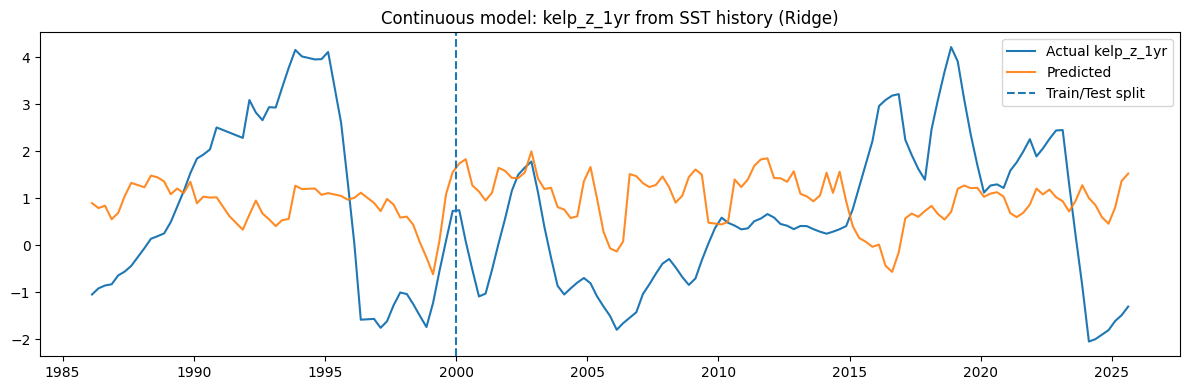

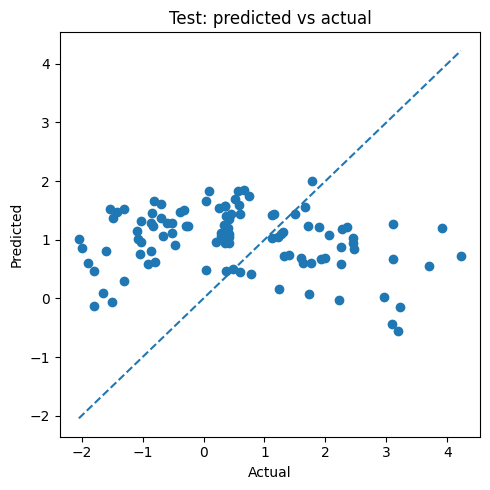

In [6]:
# continuous analysis, r^2 value, etc, sst is not a good predictor
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error

# load
df = pd.read_csv("../../1_DATA/processed/midcal/midcal_kelp_sst_labeled.csv",
                 index_col=0, parse_dates=True).sort_index()

# pick continuous target
ycol = "kelp_z_1yr"   # try also: "kelp_q_z"
# if kelp_z_1yr isn't present in your CSV, use kelp_q_z or re-save with kelp_z_1yr
if ycol not in df.columns:
    raise KeyError(f"Missing {ycol}. Columns: {list(df.columns)}")

# build "memory" SST features that match suppression timescale
df["sst_lag0"] = df["sstanom_q_mean"]
df["sst_lag1"] = df["sstanom_q_mean"].shift(1)
df["sst_lag2"] = df["sstanom_q_mean"].shift(2)
df["sst_lag3"] = df["sstanom_q_mean"].shift(3)
df["sst_prevyear_mean"] = df["sstanom_q_mean"].shift(1).rolling(4, min_periods=4).mean()  # previous year ending last quarter
df["sst_prevyear_max"]  = df["sstanom_q_max"].shift(1).rolling(4, min_periods=4).max()

features = ["sst_lag0","sst_lag1","sst_lag2","sst_lag3","sst_prevyear_mean","sst_prevyear_max"]

d = df.dropna(subset=features + [ycol]).copy()
X = d[features]
y = d[ycol].astype(float)

# time split (same as before)
train = d.index < split_date
test  = d.index >= split_date

model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

model.fit(X[train], y[train])
pred = pd.Series(model.predict(X), index=d.index)

print("Train n:", train.sum(), "Test n:", test.sum())
print("Test R^2 :", r2_score(y[test], pred[test]))
print("Test MAE :", mean_absolute_error(y[test], pred[test]))

# coefficients (on standardized X): magnitude = importance, sign = direction
coef = pd.Series(model.named_steps["ridge"].coef_, index=features).sort_values()
print("\nRidge coefficients (standardized features):")
print(coef)

# --- Visualization 1: time series actual vs predicted ---
plt.figure(figsize=(12,4))
plt.plot(y.index, y.values, label=f"Actual {ycol}")
plt.plot(pred.index, pred.values, label="Predicted", alpha=0.9)
plt.axvline(pd.Timestamp(split_date), linestyle="--", label="Train/Test split")
plt.title(f"Continuous model: {ycol} from SST history (Ridge)")
plt.legend()
plt.tight_layout()
plt.show()

# --- Visualization 2: scatter predicted vs actual (test) ---
plt.figure(figsize=(5,5))
plt.scatter(y[test], pred[test])
lims = [min(y[test].min(), pred[test].min()), max(y[test].max(), pred[test].max())]
plt.plot(lims, lims, linestyle="--")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Test: predicted vs actual")
plt.tight_layout()
plt.show()